<a href="https://colab.research.google.com/github/solven139/Black-Schores-model/blob/main/Market_Inefficiency_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas numpy matplotlib seaborn

In [ ]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.5 MB/s eta 0:00:00


Does the 10% price limit in Taiwan stock market create persistent mispricing or lead-lag effects?

Analyzing 17 tickers from 2025-03-12 to 2026-03-12...
------------------------------
BACKTEST RESULTS
------------------------------
Total Limit-Up Events Analyzed: 44
Win Rate (Next day closed strictly > 0%): 68.18%
Average Next Day Return: 3.05%
Median Next Day Return: 2.08%


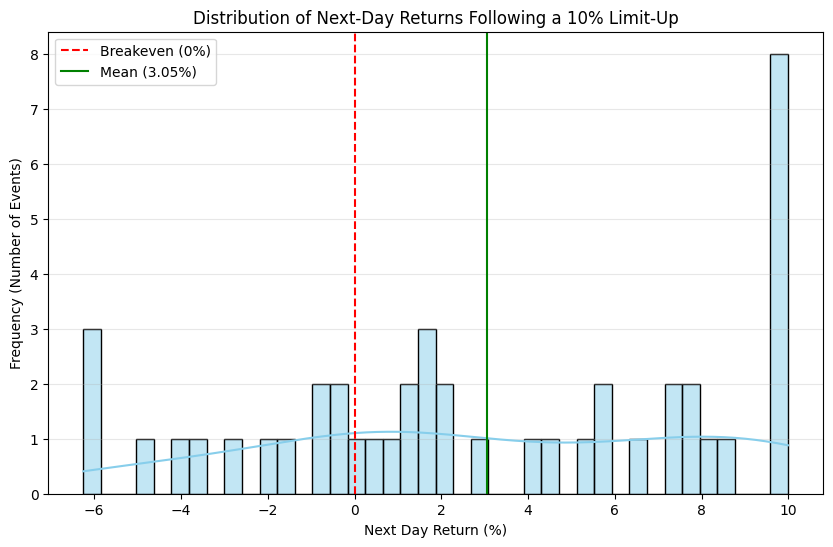

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def analyze_limit_up_strategy(tickers, days_back=365):
    """
    Analyzes the next-day return of stocks that hit a ~10% limit up.
    """
    end_date = datetime.today()
    start_date = end_date - timedelta(days=days_back)

    all_next_day_returns = []

    print(f"Analyzing {len(tickers)} tickers from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")

    for ticker in tickers:
        try:
            # Fetch historical data
            stock = yf.Ticker(ticker)
            df = stock.history(start=start_date, end=end_date)

            if df.empty:
                continue

            # Calculate daily returns (Close to previous Close)
            df['Return'] = df['Close'].pct_change()

            # Identify Limit-Up days.
            # Note: TWSE 10% limit is calculated by tick sizes, so a limit up
            # might technically be 9.8% or 9.9%. We use >= 0.098 to be safe.
            limit_up_days = df[df['Return'] >= 0.098].index

            for date in limit_up_days:
                # Find the row index of the limit up day
                idx = df.index.get_loc(date)

                # Check if there is a next trading day available in our dataset
                if idx + 1 < len(df):
                    next_day_return = df['Return'].iloc[idx + 1]
                    all_next_day_returns.append(next_day_return)

        except Exception as e:
            print(f"Could not process {ticker}: {e}")

    return all_next_day_returns

# --- Setup the Ticker List ---
# Note: To do this for the *entire* market, you would need a CSV or list of all ~1700 TWSE tickers.
# For this example, we will use a basket of highly traded Taiwan stocks (.TW suffix for TWSE, .TWO for TPEx).
sample_tw_tickers = [
    '2330.TW', '2317.TW', '2454.TW', '2382.TW', '2308.TW', # Large caps
    '2603.TW', '2609.TW', '2615.TW',                       # Shipping
    '3231.TW', '2376.TW', '2356.TW',                       # Tech/AI servers
    '1503.TW', '1519.TW', '1513.TW',                       # Electrics/Heavy Machinery
    '3443.TW', '3661.TW', '3034.TW'                        # IC Design
]

# Run the analysis for the past 1 year
returns_list = analyze_limit_up_strategy(sample_tw_tickers, days_back=365)

# --- Statistical Analysis & Visualization ---
if returns_list:
    returns_series = pd.Series(returns_list).dropna()

    # Calculate statistics
    total_events = len(returns_series)
    win_rate = (returns_series > 0).mean()
    mean_return = returns_series.mean()
    median_return = returns_series.median()

    print("-" * 30)
    print("BACKTEST RESULTS")
    print("-" * 30)
    print(f"Total Limit-Up Events Analyzed: {total_events}")
    print(f"Win Rate (Next day closed strictly > 0%): {win_rate:.2%}")
    print(f"Average Next Day Return: {mean_return:.2%}")
    print(f"Median Next Day Return: {median_return:.2%}")

    # Plotting the distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(returns_series * 100, bins=40, kde=True, color='skyblue')
    plt.axvline(x=0, color='red', linestyle='--', label='Breakeven (0%)')
    plt.axvline(x=mean_return * 100, color='green', linestyle='-', label=f'Mean ({mean_return*100:.2f}%)')

    plt.title('Distribution of Next-Day Returns Following a 10% Limit-Up')
    plt.xlabel('Next Day Return (%)')
    plt.ylabel('Frequency (Number of Events)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("No limit-up events found or data could not be fetched.")

How will they perform under different market conditions?

Fetching Market Index (^TWII) data from 2014 to build SMAs...

Calculating Markov Transition Matrix...


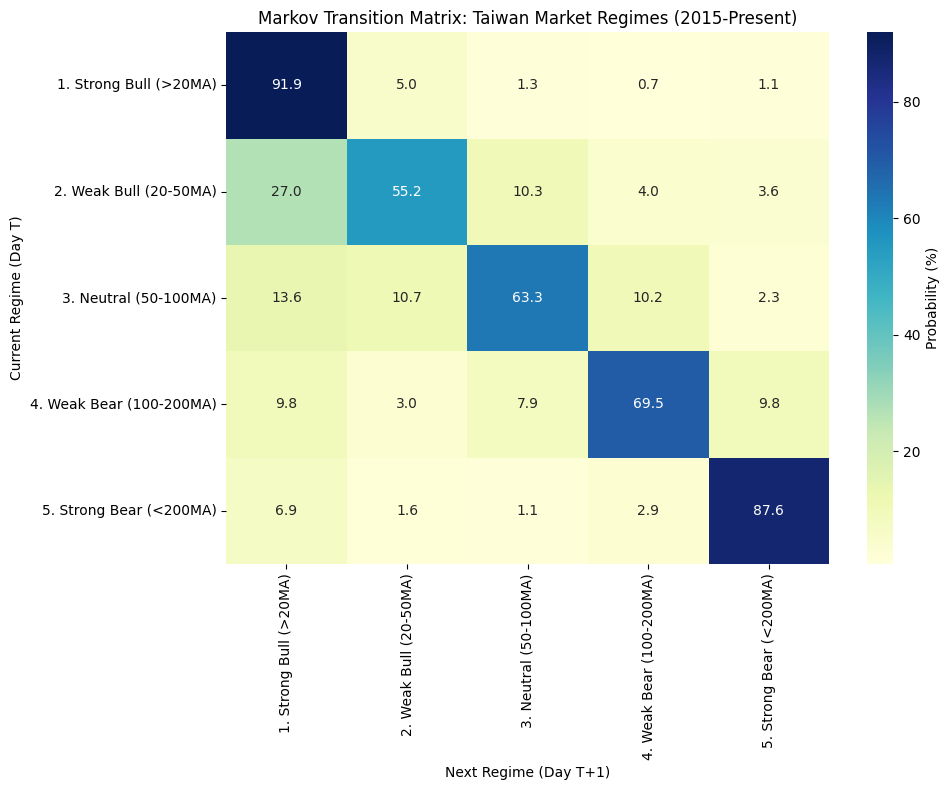

Fetching 300 tickers directly from the TWSE official site...


/tmp/ipykernel_143/2106882936.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(res.text)


Starting 10-year backtest on 300 stocks from 2015-06-01...
Processing batch 0/300...


/tmp/ipykernel_143/2106882936.py:102: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=ACTUAL_START_DATE, progress=False, group_by='ticker')
/tmp/ipykernel_143/2106882936.py:113: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['Close'].pct_change()
/tmp/ipykernel_143/2106882936.py:102: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=ACTUAL_START_DATE, progress=False, group_by='ticker')


Batch error: Cannot join tz-naive with tz-aware DatetimeIndex
Processing batch 50/300...


...

/tmp/ipykernel_143/2106882936.py:113: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['Close'].pct_change()
/tmp/ipykernel_143/2106882936.py:102: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=ACTUAL_START_DATE, progress=False, group_by='ticker')


Batch error: Cannot join tz-naive with tz-aware DatetimeIndex
Processing batch 200/300...


/tmp/ipykernel_143/2106882936.py:113: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['Close'].pct_change()
/tmp/ipykernel_143/2106882936.py:102: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(batch, start=ACTUAL_START_DATE, progress=False, group_by='ticker')


Batch error: Cannot join tz-naive with tz-aware DatetimeIndex
Processing batch 250/300...
Batch error: Cannot join tz-naive with tz-aware DatetimeIndex
No events found. The volume + limit-up filter is very strict.


/tmp/ipykernel_143/2106882936.py:113: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['Close'].pct_change()


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import requests

# --- Configuration ---
INDEX_START_DATE = "2014-06-01"
ACTUAL_START_DATE = "2015-06-01"
MIN_LIMIT_UP = 0.095
VOLUME_SPIKE_MULTIPLIER = 2.0  # Volume must be 2x the 5-day average

def get_market_regime():
    """Fetches ^TWII, calculates SMAs, and assigns daily regimes."""
    print("Fetching Market Index (^TWII) data from 2014 to build SMAs...")
    twii = yf.Ticker("^TWII")
    df = twii.history(start=INDEX_START_DATE)

    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_100'] = df['Close'].rolling(window=100).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    def determine_regime(row):
        price = row['Close']
        if pd.isna(row['SMA_200']): return "Unknown"

        if price > row['SMA_20']: return "1. Strong Bull (>20MA)"
        elif price > row['SMA_50']: return "2. Weak Bull (20-50MA)"
        elif price > row['SMA_100']: return "3. Neutral (50-100MA)"
        elif price > row['SMA_200']: return "4. Weak Bear (100-200MA)"
        else: return "5. Strong Bear (<200MA)"

    df['Regime'] = df.apply(determine_regime, axis=1)
    df = df.loc[ACTUAL_START_DATE:]
    return df[['Close', 'Regime']]

def calculate_transition_matrix(regime_series):
    """Calculates and plots the Markov Regime Transition Matrix."""
    print("\nCalculating Markov Transition Matrix...")
    df_trans = pd.DataFrame({
        'Current_State': regime_series,
        'Next_State': regime_series.shift(-1)
    }).dropna()

    transition_matrix = pd.crosstab(
        df_trans['Current_State'],
        df_trans['Next_State'],
        normalize='index'
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(transition_matrix * 100, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Probability (%)'})
    plt.title('Markov Transition Matrix: Taiwan Market Regimes (2015-Present)')
    plt.ylabel('Current Regime (Day T)')
    plt.xlabel('Next Regime (Day T+1)')
    plt.tight_layout()
    plt.show()

    return transition_matrix

def get_twse_tickers(sample_size=200):
    """Fetches active Taiwan tickers directly from TWSE without twstock."""
    print(f"Fetching {sample_size} tickers directly from the TWSE official site...")
    url = "https://isin.twse.com.tw/isin/C_public.jsp?strMode=2"

    try:
        res = requests.get(url)
        res.encoding = 'big5'
        tables = pd.read_html(res.text)
        df = tables[0]

        df.columns = df.iloc[0]
        df = df.iloc[2:]

        tickers = []
        for val in df['有價證券代號及名稱'].dropna():
            code = str(val).replace('　', ' ').split(' ')[0]
            if len(code) == 4 and code.isdigit():
                tickers.append(f"{code}.TW")

        # To run on ALL stocks, change to: return tickers
        return random.sample(tickers, min(sample_size, len(tickers)))
    except Exception as e:
        print(f"Failed to fetch from TWSE: {e}")
        return ["2330.TW", "2317.TW", "2454.TW"] # Safe fallback

def backtest_regimes_with_volume(tickers, market_df):
    """Runs the 10% limit-up + Volume Spike strategy backtest."""
    results = []
    total = len(tickers)
    print(f"Starting 10-year backtest on {total} stocks from {ACTUAL_START_DATE}...")

    batch_size = 50
    for i in range(0, total, batch_size):
        batch = tickers[i:i+batch_size]
        print(f"Processing batch {i}/{total}...")

        try:
            data = yf.download(batch, start=ACTUAL_START_DATE, progress=False, group_by='ticker')
            if len(batch) == 1:
                data.columns = pd.MultiIndex.from_product([batch, data.columns])

            for ticker in batch:
                if ticker not in data.columns.levels[0]: continue

                df = data[ticker].copy()
                if df.empty: continue

                # Calculate Price Return and Next Day Return
                df['Return'] = df['Close'].pct_change()
                df['Next_Day_Return'] = df['Return'].shift(-1)

                # Calculate 5-Day Volume Moving Average
                df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()

                # APPLY THE FILTERS: Limit Up AND Volume Spike
                limit_ups = df[
                    (df['Return'] >= MIN_LIMIT_UP) &
                    (df['Volume'] > df['Volume_MA5'] * VOLUME_SPIKE_MULTIPLIER)
                ].copy()

                merged = limit_ups.join(market_df[['Regime']], how='inner')

                for date, row in merged.iterrows():
                    if pd.notna(row['Next_Day_Return']):
                        results.append({
                            'Ticker': ticker,
                            'Date': date,
                            'Regime': row['Regime'],
                            'Limit_Up_Return': row['Return'],
                            'Volume_Spike_Ratio': row['Volume'] / row['Volume_MA5'],
                            'Next_Day_Return': row['Next_Day_Return']
                        })
        except Exception as e:
            print(f"Batch error: {e}")

    return pd.DataFrame(results)

# --- Execution ---
market_data = get_market_regime()
trans_matrix = calculate_transition_matrix(market_data['Regime'])

# Using the new dependency-free fetcher
ticker_list = get_twse_tickers(sample_size=300)
df_results = backtest_regimes_with_volume(ticker_list, market_data)

# --- Visualization ---
if not df_results.empty:
    print("\n--- Strategy Performance (With Volume Filter) ---")
    summary = df_results.groupby('Regime')['Next_Day_Return'].agg(
        Events='count',
        Win_Rate=lambda x: (x > 0).mean(),
        Avg_Return='mean',
        Median='median'
    ).sort_index()
    print(summary)

    g = sns.FacetGrid(df_results, col="Regime", col_wrap=3, height=4, sharex=True, sharey=False)
    g.map(sns.histplot, "Next_Day_Return", kde=True, bins=40, color='indigo')
    g.map(plt.axvline, x=0, color='red', linestyle='--')
    g.fig.suptitle('Probability Distributions of Returns by Regime (Volume Filtered)', y=1.02)
    plt.show()
else:
    print("No events found. The volume + limit-up filter is very strict.")

How does mometum last after a day of the selected limit-up stocks under different regimes?

Fetching Market Index (^TWII) data...


/tmp/ipykernel_143/2246890388.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')


Processing limit-up events (this takes a few seconds)...

Successfully found 1297 limit-up events across the regimes!

--- Summary Statistics ---
                          Events  Win_Rate  Avg_Return
Regime                                                
1. Strong Bull (>20MA)       856  0.568925    1.471600
2. Weak Bull (20-50MA)        77  0.389610   -0.154816
3. Neutral (50-100MA)         79  0.670886    2.291889
4. Weak Bear (100-200MA)      47  0.489362    0.572977
5. Strong Bear (<200MA)      238  0.659664    2.287843


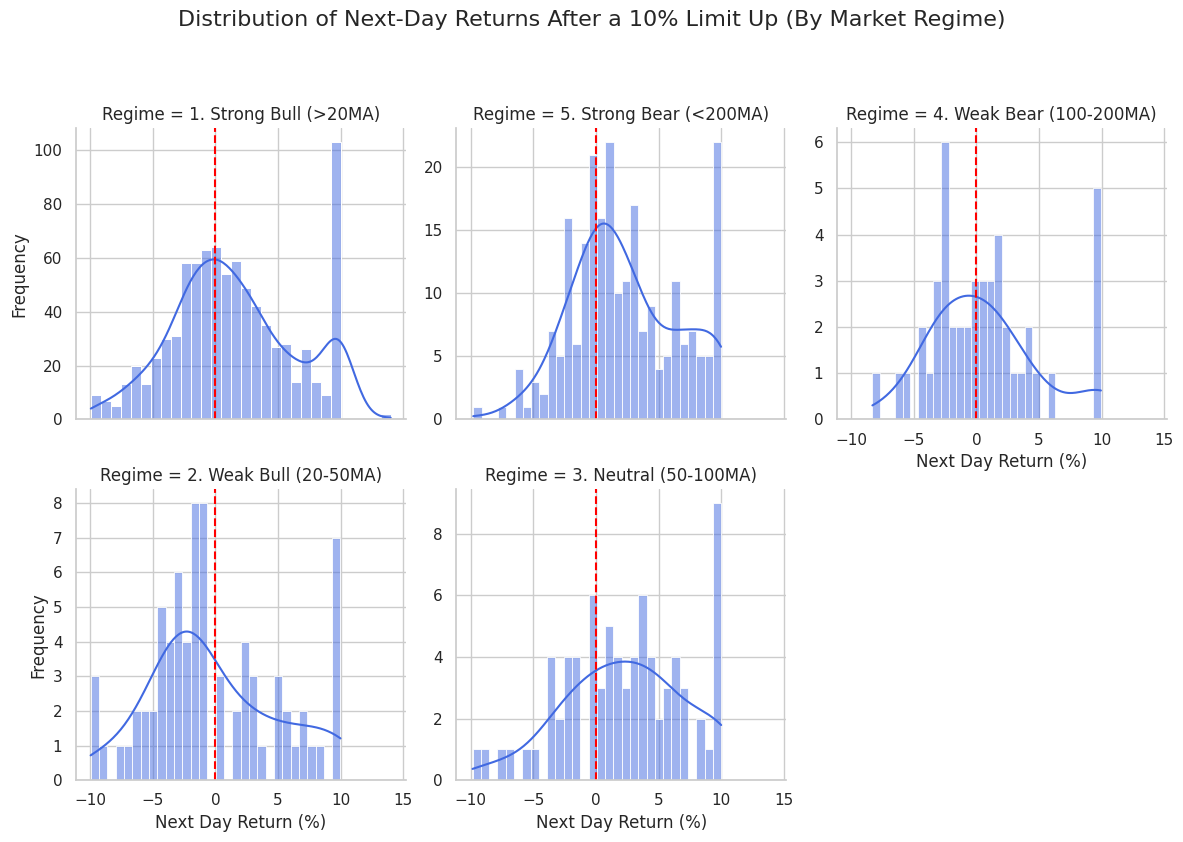

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Configuration ---
START_DATE = "2015-06-01"
MIN_LIMIT_UP = 0.095

# --- 2. Market Regime Calculation ---
def get_market_regime():
    print("Fetching Market Index (^TWII) data...")
    twii = yf.Ticker("^TWII")
    df = twii.history(start="2014-06-01")

    # STRIP TIMEZONE HERE to prevent the join error
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_100'] = df['Close'].rolling(window=100).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    def determine_regime(row):
        price = row['Close']
        if pd.isna(row['SMA_200']): return "Unknown"

        if price > row['SMA_20']: return "1. Strong Bull (>20MA)"
        elif price > row['SMA_50']: return "2. Weak Bull (20-50MA)"
        elif price > row['SMA_100']: return "3. Neutral (50-100MA)"
        elif price > row['SMA_200']: return "4. Weak Bear (100-200MA)"
        else: return "5. Strong Bear (<200MA)"

    df['Regime'] = df.apply(determine_regime, axis=1)
    return df.loc[START_DATE:][['Regime']]

# --- 3. Hardcoded List of Active Taiwan Stocks ---
sample_tickers = [
    '2330.TW', '2317.TW', '2454.TW', '2382.TW', '2308.TW', '3231.TW', '2603.TW', '2609.TW', '2615.TW', '1519.TW',
    '1503.TW', '1513.TW', '3443.TW', '3661.TW', '3034.TW', '2376.TW', '2356.TW', '2301.TW', '2303.TW', '2881.TW',
    '2882.TW', '2883.TW', '2884.TW', '2885.TW', '2886.TW', '2891.TW', '2892.TW', '2002.TW', '1101.TW', '1102.TW',
    '1216.TW', '1301.TW', '1303.TW', '1326.TW', '1402.TW', '2105.TW', '2207.TW', '2324.TW', '2345.TW', '2353.TW',
    '2357.TW', '2395.TW', '2408.TW', '2409.TW', '2412.TW', '2474.TW', '2498.TW', '3008.TW', '3045.TW', '3711.TW',
    '4904.TW', '4938.TW', '5871.TW', '6505.TW', '8046.TW', '9904.TW', '9910.TW', '3037.TW', '2313.TW', '2362.TW',
    '2377.TW', '2385.TW', '2449.TW', '2542.TW', '2606.TW', '2610.TW', '2618.TW', '2812.TW', '2834.TW', '2845.TW',
    '2880.TW', '2887.TW', '2889.TW', '2890.TW', '2912.TW', '3044.TW', '3481.TW', '3702.TW', '4958.TW', '5880.TW',
    '6239.TW', '8454.TW', '9921.TW', '9945.TW', '6669.TW', '3532.TW', '1560.TW', '1590.TW', '1605.TW', '1717.TW',
    '1722.TW', '1795.TW', '1802.TW', '1904.TW', '1907.TW', '2006.TW'
]

# --- 4. Core Backtest Logic ---
def get_distributions(tickers, market_df):
    results = []
    print(f"Downloading historical data for {len(tickers)} stocks...")

    # yfinance changed how auto_adjust works, ignore the warning it gives
    data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')

    print("Processing limit-up events (this takes a few seconds)...")
    for ticker in tickers:
        if ticker not in data.columns.levels[0]: continue

        df = data[ticker].copy()
        if df.empty: continue

        # STRIP TIMEZONE HERE to prevent the join error
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        # Calculate Returns
        df['Return'] = df['Close'].pct_change()
        df['Next_Day_Return'] = df['Return'].shift(-1) * 100

        # Filter for Limit Up Days
        limit_ups = df[df['Return'] >= MIN_LIMIT_UP].copy()

        # Merge with the Market Regime
        merged = limit_ups.join(market_df, how='inner')

        for date, row in merged.iterrows():
            if pd.notna(row['Next_Day_Return']):
                results.append({
                    'Ticker': ticker,
                    'Date': date,
                    'Regime': row['Regime'],
                    'Next_Day_Return (%)': row['Next_Day_Return']
                })

    return pd.DataFrame(results)

# --- 5. Execute and Plot ---
market_data = get_market_regime()
df_results = get_distributions(sample_tickers, market_data)

if not df_results.empty:
    print(f"\nSuccessfully found {len(df_results)} limit-up events across the regimes!")

    print("\n--- Summary Statistics ---")
    summary = df_results.groupby('Regime')['Next_Day_Return (%)'].agg(
        Events='count',
        Win_Rate=lambda x: (x > 0).mean(),
        Avg_Return='mean'
    ).sort_index()
    print(summary)

    sns.set_theme(style="whitegrid")

    g = sns.FacetGrid(df_results, col="Regime", col_wrap=3, height=4, sharex=True, sharey=False)
    g.map(sns.histplot, "Next_Day_Return (%)", kde=True, bins=30, color='royalblue', edgecolor='white')
    g.map(plt.axvline, x=0, color='red', linestyle='--', linewidth=1.5, label="0% Breakeven")

    g.fig.suptitle('Distribution of Next-Day Returns After a 10% Limit Up (By Market Regime)', y=1.05, fontsize=16)
    g.set_axis_labels("Next Day Return (%)", "Frequency")
    plt.tight_layout()
    plt.show()

else:
    print("No events found. Please check data connection.")

A day is too noisy, what of a week, a month, even further?

Fetching Market Index (^TWII) data...


/tmp/ipykernel_143/2534828301.py:65: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')


Calculating forward returns for 1D, 5D, 21D, 63D, and 126D...

Successfully processed 1298 limit-up events!

--- Average Cumulative Returns (%) by Horizon ---
                          1_Day  1_Week  1_Month  1_Quarter  6_Months
Regime                                                               
1. Strong Bull (>20MA)     1.47    2.67     6.89      17.93     38.40
2. Weak Bull (20-50MA)    -0.15   -2.61    -0.08       6.91     20.53
3. Neutral (50-100MA)      2.29    6.43    22.81      22.96     27.63
4. Weak Bear (100-200MA)   0.57    4.58     8.78      25.75     30.43
5. Strong Bear (<200MA)    2.29    4.22    10.22      17.25     30.03


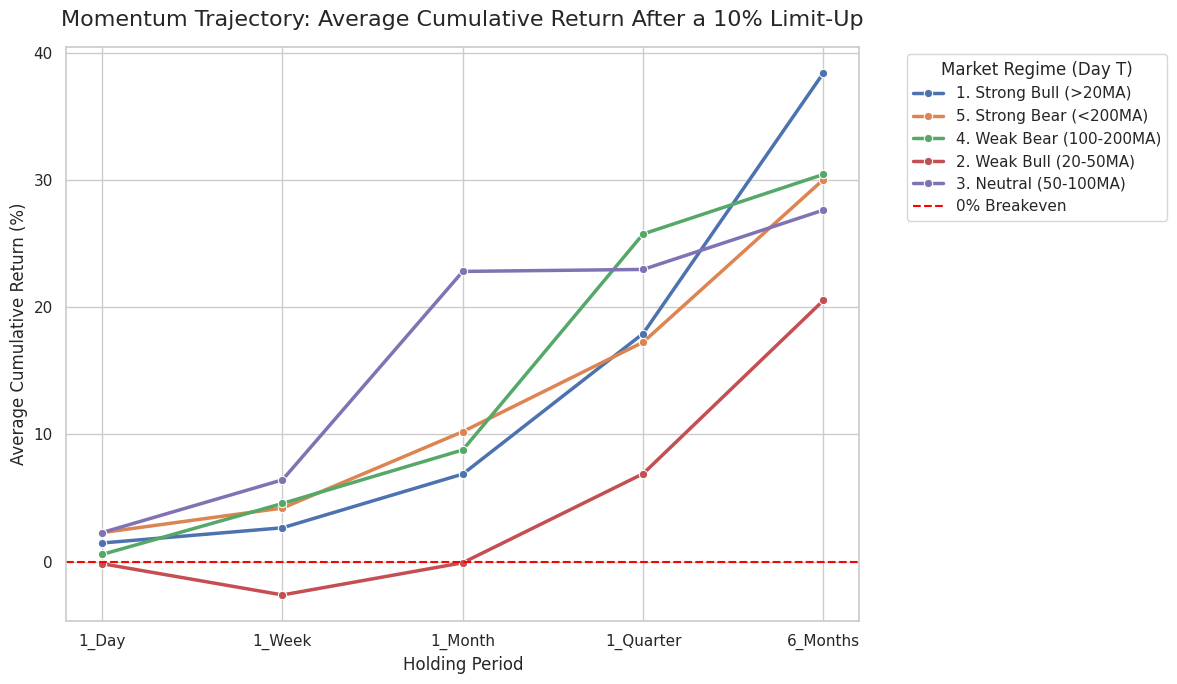

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Configuration ---
START_DATE = "2015-06-01"
MIN_LIMIT_UP = 0.095

# Define our trading horizons (in trading days)
HORIZONS = {
    '1_Day': 1,
    '1_Week': 5,
    '1_Month': 21,
    '1_Quarter': 63,
    '6_Months': 126
}

# --- 2. Market Regime Calculation ---
def get_market_regime():
    print("Fetching Market Index (^TWII) data...")
    twii = yf.Ticker("^TWII")
    df = twii.history(start="2014-06-01")

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_100'] = df['Close'].rolling(window=100).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    def determine_regime(row):
        price = row['Close']
        if pd.isna(row['SMA_200']): return "Unknown"

        if price > row['SMA_20']: return "1. Strong Bull (>20MA)"
        elif price > row['SMA_50']: return "2. Weak Bull (20-50MA)"
        elif price > row['SMA_100']: return "3. Neutral (50-100MA)"
        elif price > row['SMA_200']: return "4. Weak Bear (100-200MA)"
        else: return "5. Strong Bear (<200MA)"

    df['Regime'] = df.apply(determine_regime, axis=1)
    return df.loc[START_DATE:][['Regime']]

# --- 3. Hardcoded List of Active Taiwan Stocks ---
sample_tickers = [
    '2330.TW', '2317.TW', '2454.TW', '2382.TW', '2308.TW', '3231.TW', '2603.TW', '2609.TW', '2615.TW', '1519.TW',
    '1503.TW', '1513.TW', '3443.TW', '3661.TW', '3034.TW', '2376.TW', '2356.TW', '2301.TW', '2303.TW', '2881.TW',
    '2882.TW', '2883.TW', '2884.TW', '2885.TW', '2886.TW', '2891.TW', '2892.TW', '2002.TW', '1101.TW', '1102.TW',
    '1216.TW', '1301.TW', '1303.TW', '1326.TW', '1402.TW', '2105.TW', '2207.TW', '2324.TW', '2345.TW', '2353.TW',
    '2357.TW', '2395.TW', '2408.TW', '2409.TW', '2412.TW', '2474.TW', '2498.TW', '3008.TW', '3045.TW', '3711.TW',
    '4904.TW', '4938.TW', '5871.TW', '6505.TW', '8046.TW', '9904.TW', '9910.TW', '3037.TW', '2313.TW', '2362.TW',
    '2377.TW', '2385.TW', '2449.TW', '2542.TW', '2606.TW', '2610.TW', '2618.TW', '2812.TW', '2834.TW', '2845.TW',
    '2880.TW', '2887.TW', '2889.TW', '2890.TW', '2912.TW', '3044.TW', '3481.TW', '3702.TW', '4958.TW', '5880.TW',
    '6239.TW', '8454.TW', '9921.TW', '9945.TW', '6669.TW', '3532.TW', '1560.TW', '1590.TW', '1605.TW', '1717.TW',
    '1722.TW', '1795.TW', '1802.TW', '1904.TW', '1907.TW', '2006.TW'
]

# --- 4. Core Backtest Logic for Multiple Horizons ---
def get_multi_horizon_returns(tickers, market_df):
    results = []
    print(f"Downloading historical data for {len(tickers)} stocks...")
    data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')

    print("Calculating forward returns for 1D, 5D, 21D, 63D, and 126D...")
    for ticker in tickers:
        if ticker not in data.columns.levels[0]: continue

        df = data[ticker].copy()
        if df.empty: continue

        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        # Daily return to identify limit-ups
        df['Daily_Return'] = df['Close'].pct_change()

        # Calculate Forward Returns for all horizons
        for name, days in HORIZONS.items():
            # Formula: (Price at T+days / Price at T) - 1
            df[name] = (df['Close'].shift(-days) / df['Close']) - 1

        # Filter for Limit Up Days
        limit_ups = df[df['Daily_Return'] >= MIN_LIMIT_UP].copy()

        # Merge with the Market Regime
        merged = limit_ups.join(market_df, how='inner')

        for date, row in merged.iterrows():
            # We append the data even if long-term horizons are NaN (e.g., limit up happened yesterday)
            results.append({
                'Ticker': ticker,
                'Date': date,
                'Regime': row['Regime'],
                '1_Day': row['1_Day'] * 100,
                '1_Week': row['1_Week'] * 100,
                '1_Month': row['1_Month'] * 100,
                '1_Quarter': row['1_Quarter'] * 100,
                '6_Months': row['6_Months'] * 100
            })

    return pd.DataFrame(results)

# --- 5. Execute and Plot ---
market_data = get_market_regime()
df_results = get_multi_horizon_returns(sample_tickers, market_data)

if not df_results.empty:
    print(f"\nSuccessfully processed {len(df_results)} limit-up events!")

    # 1. Summary Table - Average Returns across horizons
    print("\n--- Average Cumulative Returns (%) by Horizon ---")
    summary_mean = df_results.groupby('Regime')[['1_Day', '1_Week', '1_Month', '1_Quarter', '6_Months']].mean()
    print(summary_mean.round(2))

    # 2. Data Transformation for Seaborn Plotting
    # Melt the dataframe to make it long-form (better for line charts)
    df_melted = df_results.melt(
        id_vars=['Ticker', 'Date', 'Regime'],
        value_vars=['1_Day', '1_Week', '1_Month', '1_Quarter', '6_Months'],
        var_name='Time_Horizon',
        value_name='Cumulative_Return_%'
    )

    # Ensure correct categorical order for the X-axis
    horizon_order = ['1_Day', '1_Week', '1_Month', '1_Quarter', '6_Months']
    df_melted['Time_Horizon'] = pd.Categorical(df_melted['Time_Horizon'], categories=horizon_order, ordered=True)

    # 3. Plotting the Trajectories
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    # lineplot automatically calculates the mean and 95% confidence interval for each point
    ax = sns.lineplot(
        data=df_melted,
        x='Time_Horizon',
        y='Cumulative_Return_%',
        hue='Regime',
        marker='o',
        linewidth=2.5,
        errorbar=None # Turn off confidence intervals for a cleaner look, change to ('ci', 95) if you want them
    )

    plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label="0% Breakeven")
    plt.title('Momentum Trajectory: Average Cumulative Return After a 10% Limit-Up', fontsize=16, pad=15)
    plt.xlabel('Holding Period', fontsize=12)
    plt.ylabel('Average Cumulative Return (%)', fontsize=12)
    plt.legend(title='Market Regime (Day T)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

else:
    print("No events found. Please check data connection.")

Are the results counter intuitive?

Fetching Market Index (^TWII) data...


/tmp/ipykernel_143/1700788746.py:64: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')


Calculating metrics...


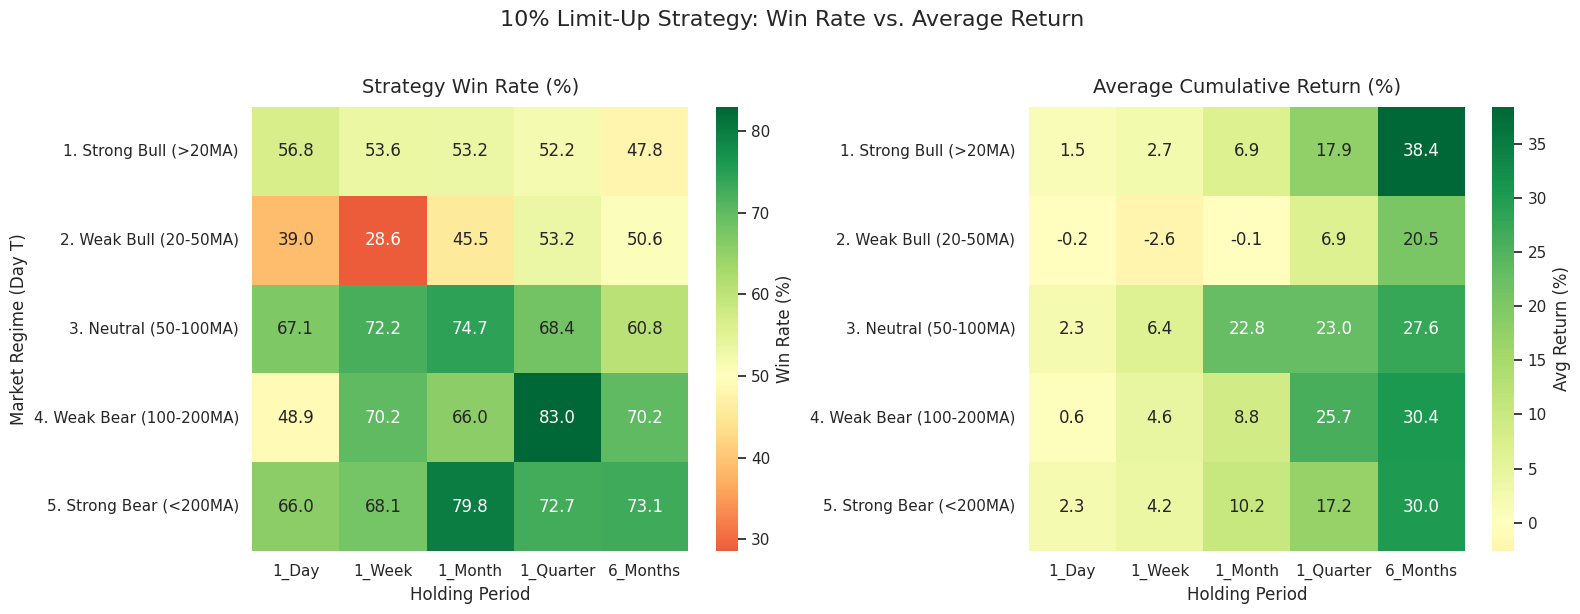

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Configuration ---
START_DATE = "2015-06-01"
MIN_LIMIT_UP = 0.095

HORIZONS = {
    '1_Day': 1,
    '1_Week': 5,
    '1_Month': 21,
    '1_Quarter': 63,
    '6_Months': 126
}

# --- 2. Market Regime Calculation ---
def get_market_regime():
    print("Fetching Market Index (^TWII) data...")
    twii = yf.Ticker("^TWII")
    df = twii.history(start="2014-06-01")

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['SMA_100'] = df['Close'].rolling(window=100).mean()
    df['SMA_200'] = df['Close'].rolling(window=200).mean()

    def determine_regime(row):
        price = row['Close']
        if pd.isna(row['SMA_200']): return "Unknown"

        if price > row['SMA_20']: return "1. Strong Bull (>20MA)"
        elif price > row['SMA_50']: return "2. Weak Bull (20-50MA)"
        elif price > row['SMA_100']: return "3. Neutral (50-100MA)"
        elif price > row['SMA_200']: return "4. Weak Bear (100-200MA)"
        else: return "5. Strong Bear (<200MA)"

    df['Regime'] = df.apply(determine_regime, axis=1)
    return df.loc[START_DATE:][['Regime']]

# --- 3. Hardcoded List of Active Taiwan Stocks ---
sample_tickers = [
    '2330.TW', '2317.TW', '2454.TW', '2382.TW', '2308.TW', '3231.TW', '2603.TW', '2609.TW', '2615.TW', '1519.TW',
    '1503.TW', '1513.TW', '3443.TW', '3661.TW', '3034.TW', '2376.TW', '2356.TW', '2301.TW', '2303.TW', '2881.TW',
    '2882.TW', '2883.TW', '2884.TW', '2885.TW', '2886.TW', '2891.TW', '2892.TW', '2002.TW', '1101.TW', '1102.TW',
    '1216.TW', '1301.TW', '1303.TW', '1326.TW', '1402.TW', '2105.TW', '2207.TW', '2324.TW', '2345.TW', '2353.TW',
    '2357.TW', '2395.TW', '2408.TW', '2409.TW', '2412.TW', '2474.TW', '2498.TW', '3008.TW', '3045.TW', '3711.TW',
    '4904.TW', '4938.TW', '5871.TW', '6505.TW', '8046.TW', '9904.TW', '9910.TW', '3037.TW', '2313.TW', '2362.TW',
    '2377.TW', '2385.TW', '2449.TW', '2542.TW', '2606.TW', '2610.TW', '2618.TW', '2812.TW', '2834.TW', '2845.TW',
    '2880.TW', '2887.TW', '2889.TW', '2890.TW', '2912.TW', '3044.TW', '3481.TW', '3702.TW', '4958.TW', '5880.TW',
    '6239.TW', '8454.TW', '9921.TW', '9945.TW', '6669.TW', '3532.TW', '1560.TW', '1590.TW', '1605.TW', '1717.TW',
    '1722.TW', '1795.TW', '1802.TW', '1904.TW', '1907.TW', '2006.TW'
]

# --- 4. Core Logic ---
def get_multi_horizon_data(tickers, market_df):
    results = []
    print(f"Downloading historical data for {len(tickers)} stocks...")
    data = yf.download(tickers, start=START_DATE, progress=False, group_by='ticker')

    print("Calculating metrics...")
    for ticker in tickers:
        if ticker not in data.columns.levels[0]: continue
        df = data[ticker].copy()
        if df.empty: continue

        if df.index.tz is not None: df.index = df.index.tz_localize(None)

        df['Daily_Return'] = df['Close'].pct_change()

        for name, days in HORIZONS.items():
            df[name] = (df['Close'].shift(-days) / df['Close']) - 1

        limit_ups = df[df['Daily_Return'] >= MIN_LIMIT_UP].copy()
        merged = limit_ups.join(market_df, how='inner')

        for date, row in merged.iterrows():
            results.append({
                'Regime': row['Regime'],
                '1_Day': row['1_Day'] * 100,
                '1_Week': row['1_Week'] * 100,
                '1_Month': row['1_Month'] * 100,
                '1_Quarter': row['1_Quarter'] * 100,
                '6_Months': row['6_Months'] * 100
            })
    return pd.DataFrame(results)

# --- 5. Execute and Plot ---
market_data = get_market_regime()
df_results = get_multi_horizon_data(sample_tickers, market_data)

if not df_results.empty:
    # --- Calculate Average Returns ---
    returns_matrix = df_results.groupby('Regime')[['1_Day', '1_Week', '1_Month', '1_Quarter', '6_Months']].mean()

    # --- Calculate Win Rates ---
    # Win rate is the percentage of trades strictly greater than 0%
    win_rate_matrix = df_results.groupby('Regime')[['1_Day', '1_Week', '1_Month', '1_Quarter', '6_Months']].apply(lambda x: (x > 0).mean() * 100)

    # Reorder index to ensure chronological regime order
    regime_order = ["1. Strong Bull (>20MA)", "2. Weak Bull (20-50MA)", "3. Neutral (50-100MA)", "4. Weak Bear (100-200MA)", "5. Strong Bear (<200MA)"]
    returns_matrix = returns_matrix.reindex(regime_order)
    win_rate_matrix = win_rate_matrix.reindex(regime_order)

    # --- Plot the Side-by-Side Heatmaps ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Custom colormaps: RdYlGn (Red = Bad, Yellow = Neutral, Green = Good)
    sns.heatmap(win_rate_matrix, annot=True, fmt=".1f", cmap="RdYlGn", center=50, ax=axes[0],
                cbar_kws={'label': 'Win Rate (%)'})
    axes[0].set_title('Strategy Win Rate (%)', fontsize=14, pad=10)
    axes[0].set_ylabel('Market Regime (Day T)', fontsize=12)
    axes[0].set_xlabel('Holding Period', fontsize=12)

    sns.heatmap(returns_matrix, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[1],
                cbar_kws={'label': 'Avg Return (%)'})
    axes[1].set_title('Average Cumulative Return (%)', fontsize=14, pad=10)
    axes[1].set_ylabel('') # Hide y-label on the second chart for cleanliness
    axes[1].set_xlabel('Holding Period', fontsize=12)

    plt.suptitle('10% Limit-Up Strategy: Win Rate vs. Average Return', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

else:
    print("No events found.")

Market regime aren't really obervable, perhaps Hidden Markov Model is the solution?

Fetching Market Index (^TWII) data to fit the Hidden Markov Model...
Fitting Gaussian HMM with 3 states...

Extracting HMM Transition Matrix...


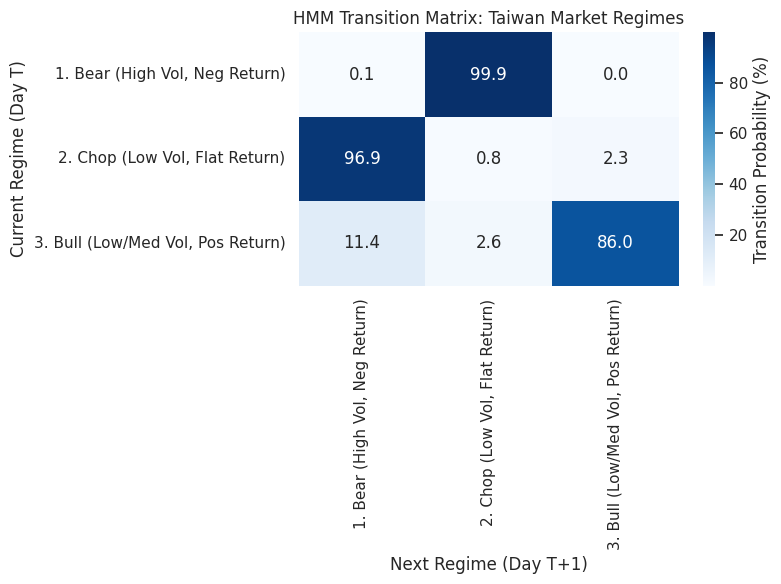

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

INDEX_START_DATE = "2014-06-01"
ACTUAL_START_DATE = "2015-06-01"

def get_hmm_market_regime(n_states=3):
    """
    Fetches ^TWII, calculates daily log returns, and fits a Gaussian HMM
    to classify the market into probabilistic hidden states.
    """
    print("Fetching Market Index (^TWII) data to fit the Hidden Markov Model...")
    twii = yf.Ticker("^TWII")
    df = twii.history(start=INDEX_START_DATE).copy()

    # Calculate daily log returns as the observable variable
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df = df.dropna()

    # hmmlearn requires a 2D array: (n_samples, n_features)
    X = df[['Log_Return']].values

    # Initialize and fit the Gaussian HMM
    print(f"Fitting Gaussian HMM with {n_states} states...")
    model = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=1000, random_state=42)
    model.fit(X)

    # Predict the most likely sequence of hidden states
    df['Hidden_State'] = model.predict(X)

    # --- Map numerical states to meaningful labels ---
    # We analyze the mean and variance of the log returns in each state
    # to label them logically (e.g., High Variance/Negative Mean = Bear)
    state_stats = []
    for i in range(n_states):
        state_returns = df[df['Hidden_State'] == i]['Log_Return']
        state_stats.append({
            'state': i,
            'mean': state_returns.mean(),
            'volatility': state_returns.std()
        })

    # Sort states by mean return (lowest to highest)
    state_stats = sorted(state_stats, key=lambda x: x['mean'])

    # Assuming n_states=3, we can assign these basic labels:
    regime_labels = {
        state_stats[0]['state']: "1. Bear (High Vol, Neg Return)",
        state_stats[1]['state']: "2. Chop (Low Vol, Flat Return)",
        state_stats[2]['state']: "3. Bull (Low/Med Vol, Pos Return)"
    }

    df['Regime'] = df['Hidden_State'].map(regime_labels)

    # Filter to actual start date for the backtest
    df = df.loc[ACTUAL_START_DATE:]

    return df[['Close', 'Regime', 'Log_Return']], model

def plot_hmm_transition_matrix(model, regime_labels):
    """
    Extracts and plots the mathematically fitted transition matrix
    directly from the HMM object.
    """
    print("\nExtracting HMM Transition Matrix...")

    # The HMM naturally learns the transition matrix during fitting!
    trans_mat = model.transmat_

    # Reorder the matrix to match our logical Bear -> Chop -> Bull order
    ordered_states = [k for k, v in sorted(regime_labels.items(), key=lambda item: item[1])]
    reordered_mat = trans_mat[ordered_states][:, ordered_states]
    ordered_labels = [regime_labels[k] for k in ordered_states]

    plt.figure(figsize=(8, 6))
    sns.heatmap(reordered_mat * 100, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=ordered_labels, yticklabels=ordered_labels,
                cbar_kws={'label': 'Transition Probability (%)'})
    plt.title('HMM Transition Matrix: Taiwan Market Regimes')
    plt.ylabel('Current Regime (Day T)')
    plt.xlabel('Next Regime (Day T+1)')
    plt.tight_layout()
    plt.show()

# --- Execution ---
market_df, hmm_model = get_hmm_market_regime(n_states=3)

# Recreate the mapping for the plotting function
mapping = {k: v for k, v in zip(
    market_df['Regime'].astype('category').cat.codes.unique(),
    market_df['Regime'].unique()
)}
plot_hmm_transition_matrix(hmm_model, mapping)